# Intro

The motivation behind this notebook is to do an EDA of the data that we joined together in the previous notebook (add_station_information_together). We want to get a handle of how much missing data there is, as well as checking correlations and seeing what variables seem to be most important to demand. We also need to get in the weather data for the trips.

# Libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os, shutil, subprocess

WORK_DIR = '/content/drive/MyDrive/DL_Project'
os.chdir(WORK_DIR)
print('cwd:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/MyDrive/DL_Project


In [4]:
import polars as pl
import matplotlib.pyplot as plt

# Data Read in

In [5]:
cabi = pl.read_parquet("data/cabi_demand_with_stations.parquet")
weather_data = pl.read_parquet("data/weather_hourly.parquet")

In [6]:
# filter for just dc
cabi = cabi.filter(pl.col("STATEFP") == "11") # filter for only cols that have the open data DC for them

# Fill Demand

In [7]:
cabi = cabi.with_columns([
    pl.col("deps").fill_null(0),
    pl.col("arrs").fill_null(0),
]).with_columns(
    (pl.col("arrs") - pl.col("deps")).alias("demand")
).filter(pl.col("start_station_id").is_not_null()) # filter out null stations

## Fill census info
just gonna use the mean, its for a select few stations that are on federal land that don't have these metrics.

In [8]:
impute_cols = ["median_ageE", "median_ageM", "median_hh_incomeE", "median_hh_incomeM"]

# Compute column means 
col_means = {
    c: cabi.select(pl.col(c).mean()).item()
    for c in impute_cols
}

# Fill nulls with the dataset mean for each column
cabi_imputed = cabi.with_columns([
    pl.col(c).fill_null(col_means[c])
    for c in impute_cols
])

# Join Weather data

In [9]:
# was getting an error with datetime differences
weather_data = weather_data.with_columns(
    pl.col("datetime").dt.replace_time_zone("UTC").alias("datetime")
)
# get this on an hourly thing so we can join the stuf
cabi_imputed = cabi_imputed.with_columns(
    pl.col("started_at_15").dt.truncate("1h").alias("started_at_hour")
)

# and join
cabi_weather = cabi_imputed.join(
    weather_data,
    left_on="started_at_hour",
    right_on="datetime",
    how="left" 
)

# Check Nulls

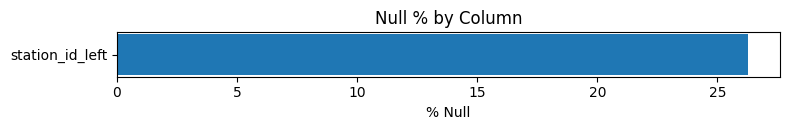

In [10]:
total_nulls = cabi_weather.null_count()

null_pct = (
    total_nulls
    .unpivot(variable_name="column", value_name="null_count")
    .with_columns((pl.col("null_count") / cabi_weather.height * 100).alias("null_pct"))
    .filter(pl.col("null_pct") > 0)
    .sort("null_pct", descending=True)
)

fig, ax = plt.subplots(figsize=(8, null_pct.height * 0.4 + 1))
ax.barh(null_pct["column"].to_list(), null_pct["null_pct"].to_list())
ax.set_xlabel("% Null")
ax.set_title("Null % by Column")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


# Variable selection

In [11]:
cabi_weather.columns

['start_station_id',
 'started_at_15',
 'deps',
 'arrs',
 'demand',
 'station_name',
 'latitude',
 'longitude',
 'n_bus_stops',
 'n_metro_stations',
 'n_commuter_bus',
 'n_tourist_bus',
 'n_carshare',
 'n_hotels',
 'n_museums',
 'n_recreation',
 'n_shopping',
 'n_universities',
 'n_schools',
 'n_schools_private',
 'n_parks',
 'n_national_parks',
 'station_id_left',
 'n_nearby_stations',
 'TRACTCE_left',
 'GEOID_left',
 'm1_1_schoo',
 'm1_2_quali',
 'm1_3_playg',
 'm1_4_cross',
 'm1_5_safe_',
 'm1_6_libra',
 'm1_7_wirel',
 'm1_8_broad',
 'm1_9_recre',
 'm2_1_commu',
 'm3_1_banks',
 'm3_2_check',
 'm4_1_quali',
 'm4_2_share',
 'm4_3_affor',
 'm4_4_vacan',
 'm5_1_buses',
 'm5_2_metro',
 'm5_3_capit',
 'm5_4_bike_',
 'm5_5_sidew',
 'm5_6_parki',
 'm6_1_groce',
 'm6_2_low_f',
 'm6_3_farme',
 'm6_4_healt',
 'm6_5_resta',
 'm6_6_liquo',
 'm7_1_healt',
 'm7_2_menta',
 'm8_1_urban',
 'm8_2_parks',
 'm8_3_trail',
 'm8_4_land_',
 'm8_5_posit',
 'm8_6_flood',
 'm9_1_vacan',
 'm9_2_stree',
 'm9_3_p

In [12]:
cabi_selected = cabi_weather.select(
    ['start_station_id',
     'year',
     'started_at_15',
     'demand',
     'latitude',
     'longitude',
     
     'n_nearby_stations',
     'n_bus_stops',         
     'n_metro_stations',     # replaces m5_2_metro
     'n_commuter_bus',       # replaces m5_1_buses (additional)
     'n_tourist_bus',
     'n_carshare',
     'n_hotels',             # paper variable
     'n_museums',            # paper variable
     'n_recreation',         # replaces m1_9_recre
     'n_shopping',           # paper variable
     'n_universities',       # paper variable
     'n_schools',            # paper variable
     'n_schools_private',
     'n_parks',              
     'n_national_parks',

     'm5_4_bike_',           # bike lane access (tract-level, intentional)
     'm5_5_sidew',           # sidewalk quality (tract-level, intentional)
     'm8_3_trail',           # trail access (tract-level, intentional)
     'm8_4_land_',           # land use mix
     'm8_5_posit',           # positive land uses
     'm8_6_flood',           # flood plains
     'm9_1_vacan',           # vacancy
     'm9_2_stree',           # streetlight coverage
     'm9_3_polic',           # proximity to police
     'm9_4_fire_',           # proximity to fire stations
     'm9_5_HIN',             # high injury network corridors
     'm6_5_resta',           # restaurants (BEI only, no buffer layer downloaded)
     'm6_6_liquo',           # liquor stores
     'm8_1_urban',           # urban tree canopy

     'total_popE',
     'pop_maleE',
     'pop_femaleE',
     'median_ageE',
     'median_hh_incomeE',

     'in_low_stress_bikeshed',
     'in_total_bikeshed',

     'temp_f',
     'precip_in']
)

In [13]:
cabi_selected.shape

(15454117, 44)

In [14]:
cabi.shape

(15454117, 156)

In [15]:
cabi_selected

start_station_id,year,started_at_15,demand,latitude,longitude,n_nearby_stations,n_bus_stops,n_metro_stations,n_commuter_bus,n_tourist_bus,n_carshare,n_hotels,n_museums,n_recreation,n_shopping,n_universities,n_schools,n_schools_private,n_parks,n_national_parks,m5_4_bike_,m5_5_sidew,m8_3_trail,m8_4_land_,m8_5_posit,m8_6_flood,m9_1_vacan,m9_2_stree,m9_3_polic,m9_4_fire_,m9_5_HIN,m6_5_resta,m6_6_liquo,m8_1_urban,total_popE,pop_maleE,pop_femaleE,median_ageE,median_hh_incomeE,in_low_stress_bikeshed,in_total_bikeshed,temp_f,precip_in
f64,f64,"datetime[μs, UTC]",i32,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
22907.0,2024.0,2026-01-15 17:00:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,28.9,0.0
22907.0,2024.0,2026-01-15 17:15:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,28.9,0.0
22907.0,2024.0,2026-01-15 17:45:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,28.9,0.0
22907.0,2024.0,2026-01-15 18:00:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,26.5,0.0
22907.0,2024.0,2026-01-15 18:15:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,26.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,2024.0,2026-03-31 20:15:00 UTC,2,38.921468,-77.035244,4.0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0.305852,0.992071,0.0,0.5825987,0.554207,1.0,0.77332,0.192352,0.999894,0.999894,0.820924,0.930103,0.000106,0.276112,2508.0,1282.0,1226.0,34.8,134508.0,1,1,78.4,0.0
33204.0,2024.0,2026-03-31 20:30:00 UTC,1,38.921468,-77.035244,4.0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0.305852,0.992071,0.0,0.5825987,0.554207,1.0,0.77332,0.192352,0.999894,0.999894,0.820924,0.930103,0.000106,0.276112,2508.0,1282.0,1226.0,34.8,134508.0,1,1,78.4,0.0
33204.0,2024.0,2026-03-31 20:45:00 UTC,1,38.921468,-77.035244,4.0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0.305852,0.992071,0.0,0.5825987,0.554207,1.0,0.77332,0.192352,0.999894,0.999894,0.820924,0.930103,0.000106,0.276112,2508.0,1282.0,1226.0,34.8,134508.0,1,1,78.4,0.0


# Feature Engineering
I want to add more variables that i think might be useful for our modeling

In [16]:
import numpy as np
# core time features
cabi_selected = cabi_selected.with_columns([
    pl.col("started_at_15").dt.hour().alias("hour"),
    pl.col("started_at_15").dt.minute().alias("minute"),
    pl.col("started_at_15").dt.weekday().alias("day_of_week"), 
    pl.col("started_at_15").dt.month().alias("month"),
    pl.col("started_at_15").dt.week().alias("week_of_year"),
    (pl.col("started_at_15").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend")
])
# add in sin / cos to capture the cycle of days

cabi_selected = cabi_selected.with_columns([ # conver to radians
    (2 * np.pi * pl.col("day_of_week") / 7).alias("_dow_rad"),
    (2 * np.pi * pl.col("week_of_year") / 52).alias("_woy_rad")
]).with_columns([
    pl.col("_dow_rad").sin().alias("day_of_week_sin"),
    pl.col("_dow_rad").cos().alias("day_of_week_cos"),
    pl.col("_woy_rad").sin().alias("week_of_year_sin"),
    pl.col("_woy_rad").cos().alias("week_of_year_cos")
]).drop(["_dow_rad", "_woy_rad"])

cabi_selected

start_station_id,year,started_at_15,demand,latitude,longitude,n_nearby_stations,n_bus_stops,n_metro_stations,n_commuter_bus,n_tourist_bus,n_carshare,n_hotels,n_museums,n_recreation,n_shopping,n_universities,n_schools,n_schools_private,n_parks,n_national_parks,m5_4_bike_,m5_5_sidew,m8_3_trail,m8_4_land_,m8_5_posit,m8_6_flood,m9_1_vacan,m9_2_stree,m9_3_polic,m9_4_fire_,m9_5_HIN,m6_5_resta,m6_6_liquo,m8_1_urban,total_popE,pop_maleE,pop_femaleE,median_ageE,median_hh_incomeE,in_low_stress_bikeshed,in_total_bikeshed,temp_f,precip_in,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos
f64,f64,"datetime[μs, UTC]",i32,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64
22907.0,2024.0,2026-01-15 17:00:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,28.9,0.0,17,0,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,2024.0,2026-01-15 17:15:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,28.9,0.0,17,15,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,2024.0,2026-01-15 17:45:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,28.9,0.0,17,45,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,2024.0,2026-01-15 18:00:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,26.5,0.0,18,0,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
22907.0,2024.0,2026-01-15 18:15:00 UTC,0,38.918767,-76.965328,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.005958,0.993762,0.241886,0.94982,0.793049,0.869033,0.956766,0.22045,0.46039,0.389143,0.858014,0.36368,0.233751,0.388847,5028.0,2653.0,2375.0,41.9,80536.0,0,1,26.5,0.0,18,15,4,1,3,0,-0.433884,-0.900969,0.354605,0.935016
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
33204.0,2024.0,2026-03-31 20:15:00 UTC,2,38.921468,-77.035244,4.0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0.305852,0.992071,0.0,0.5825987,0.554207,1.0,0.77332,0.192352,0.999894,0.999894,0.820924,0.930103,0.000106,0.276112,2508.0,1282.0,1226.0,34.8,134508.0,1,1,78.4,0.0,20,15,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537
33204.0,2024.0,2026-03-31 20:30:00 UTC,1,38.921468,-77.035244,4.0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0.305852,0.992071,0.0,0.5825987,0.554207,1.0,0.77332,0.192352,0.999894,0.999894,0.820924,0.930103,0.000106,0.276112,2508.0,1282.0,1226.0,34.8,134508.0,1,1,78.4,0.0,20,30,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537
33204.0,2024.0,2026-03-31 20:45:00 UTC,1,38.921468,-77.035244,4.0,6,6,6,6,6,6,6,6,6,6,6,6,6,6,0.305852,0.992071,0.0,0.5825987,0.554207,1.0,0.77332,0.192352,0.999894,0.999894,0.820924,0.930103,0.000106,0.276112,2508.0,1282.0,1226.0,34.8,134508.0,1,1,78.4,0.0,20,45,2,3,14,0,0.974928,-0.222521,0.992709,-0.120537


In [17]:
# Add in holiday nformation
from pandas.tseries.holiday import USFederalHolidayCalendar
hol_cal = USFederalHolidayCalendar()
holidays_pd = hol_cal.holidays(start="2022-01-01", end="2026-03-31") # based on min and max of our cabi data
# convert to polars
holidays_pl = pl.DataFrame({
    "date" : pl.Series(holidays_pd.normalize())
}).with_columns([pl.col("date").cast(pl.Date),
                pl.lit(1).cast(pl.Int8).alias("is_holiday")])
# join
cabi_selected = cabi_selected.with_columns(
    pl.col("started_at_15").dt.date().alias("date")
).join(holidays_pl, on="date", how="left").with_columns(
    pl.col("is_holiday").fill_null(0)
)

In [18]:
cabi_selected.null_count()

start_station_id,year,started_at_15,demand,latitude,longitude,n_nearby_stations,n_bus_stops,n_metro_stations,n_commuter_bus,n_tourist_bus,n_carshare,n_hotels,n_museums,n_recreation,n_shopping,n_universities,n_schools,n_schools_private,n_parks,n_national_parks,m5_4_bike_,m5_5_sidew,m8_3_trail,m8_4_land_,m8_5_posit,m8_6_flood,m9_1_vacan,m9_2_stree,m9_3_polic,m9_4_fire_,m9_5_HIN,m6_5_resta,m6_6_liquo,m8_1_urban,total_popE,pop_maleE,pop_femaleE,median_ageE,median_hh_incomeE,in_low_stress_bikeshed,in_total_bikeshed,temp_f,precip_in,hour,minute,day_of_week,month,week_of_year,is_weekend,day_of_week_sin,day_of_week_cos,week_of_year_sin,week_of_year_cos,date,is_holiday
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# write out

In [19]:
cabi_selected.write_parquet("data/cabi_master.parquet")